# The Annotated ConvNeXt: From ResNet to surpassing ViTs
### (or, a checklist of how to improve your models)

Most of the information will be taken from the "A ConvNet for the 2020s" paper at https://arxiv.org/pdf/2201.03545. It outlines a series of changes that bring the advances in Vision Transformers (ViTs) to the field of ConvNets, which results in it surpassing the ability of even Swin Transformers (at similar parameter counts). Overall, its a good trade-off!  

Enough talk though. Let's just start writing code.

To install dependencies, run `pip install torch torchvision matplotlib pytorch-lightning einops tensorboard`.

In [1]:
import torch
import torch.nn as nn

## Baseline
We will be constructing a ConvNeXt-T (tiny) model, which builds off ResNet50. The naming scheme (T, S, B...) is made to follow the labelling by Swin Transformers!  

Here is a ResNet50. Note that `bias=False` removes the bias term from the conv, which is not needed as we have BatchNorm immediately after/before, which will normalize the distribution (thus bias term is effectively pointless!)

In [2]:
class ResNetBlock(nn.Module): # written with reference to https://github.com/huggingface/pytorch-image-models/blob/main/timm/models/resnet.py
    def __init__(self, in_features, hidden_features, expansion_factor=4, downsample=False):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_features, hidden_features, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden_features),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(hidden_features, hidden_features, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_features),
            nn.ReLU()
        )
        if downsample:
            self.conv3 = nn.Sequential(
                nn.Conv2d(hidden_features, hidden_features*expansion_factor, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(hidden_features*expansion_factor)
            )
            self.downsample_conv = nn.Sequential(
                nn.Conv2d(in_features, hidden_features*expansion_factor, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(hidden_features*expansion_factor)
            )
        else:
            self.conv3 = nn.Sequential(
                nn.Conv2d(hidden_features, hidden_features*expansion_factor, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_features*expansion_factor)
            )
            self.downsample_conv = None

    def forward(self, x):
        shortcut = x

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        if self.downsample_conv is not None:
            shortcut = self.downsample_conv(shortcut)

        x = nn.functional.relu(shortcut + x)
        return x


class ResNet50(nn.Module):
    def __init__(self, in_features=3, out_features=1000, dims=[64, 128, 256, 512], layers=[3, 4, 6, 3], expansion_factor=4):
        super().__init__()
        # Stem
        self.conv1 = nn.Conv2d(in_features, dims[0]*expansion_factor, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(dims[0]*expansion_factor)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Use list comprehension to create ResNet50 layers! dims*expansion factor is due to the bottleneck design of ResNet50.
        self.layer1 = nn.Sequential(
            *[ ResNetBlock(dims[0]*expansion_factor, dims[0], expansion_factor=expansion_factor) for i in range(layers[0]) ]
        )
        self.layer2 = nn.Sequential(
            ResNetBlock(dims[0]*expansion_factor, dims[1], expansion_factor=expansion_factor, downsample=True),
            *[ ResNetBlock(dims[1]*expansion_factor, dims[1], expansion_factor=expansion_factor) for i in range(layers[1]-1) ]
        )
        self.layer3 = nn.Sequential(
            ResNetBlock(dims[1]*expansion_factor, dims[2], expansion_factor=expansion_factor, downsample=True),
            *[ ResNetBlock(dims[2]*expansion_factor, dims[2], expansion_factor=expansion_factor) for i in range(layers[2]-1) ]
        )
        self.layer4 = nn.Sequential(
            ResNetBlock(dims[2]*expansion_factor, dims[3], expansion_factor=expansion_factor, downsample=True),
            *[ ResNetBlock(dims[3]*expansion_factor, dims[3], expansion_factor=expansion_factor) for i in range(layers[3]-1) ]
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(dims[3]*expansion_factor, out_features)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

In [3]:
ResNet50()(torch.randn(1, 3, 224, 224)).shape

torch.Size([1, 1000])

## Macro Improvements (changes to model topology)
### 1. Changing stage compute ratio (Acc: 78.8% --> 79.4%)  

> The original design of the
computation distribution across stages in ResNet was largely
empirical. The heavy “res4” stage was meant to be compatible with downstream tasks like object detection, where a
detector head operates on the 14×14 feature plane. Swin-T,
on the other hand, followed the same principle but with a
slightly different stage compute ratio of 1:1:3:1. For larger
Swin Transformers, the ratio is 1:1:9:1. Following the design, we **adjust the number of blocks in each stage from
(3, 4, 6, 3) in ResNet-50 to (3, 3, 9, 3)**, which also aligns
the FLOPs with Swin-T. This improves the model accuracy
from 78.8% to 79.4%. Notably, researchers have thoroughly
investigated the distribution of computation, and a
more optimal design is likely to exist.



In [4]:
# Changes:
# - Change number of layers parameter (we update the default later)

ResNet50(layers=[3, 3, 9, 3])

ResNet50(
  (conv1): Conv2d(3, 256, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResNetBlock(
      (conv1): Sequential(
        (0): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv2): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv3): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


### 2. Changing stem to "patchify" (Acc: 79.4% --> 79.5%)
> The stem cell in standard ResNet contains a 7×7 convolution
layer with stride 2, followed by a max pool, which results
in a 4× downsampling of the input images. In vision Transformers, a more aggressive “patchify” strategy is used as
the stem cell, which corresponds to a large kernel size (e.g.
kernel size = 14 or 16) and non-overlapping convolution.
Swin Transformer uses a similar “patchify” layer, but with
a smaller patch size of 4 to accommodate the architecture’s
multi-stage design. We **replace the ResNet-style stem cell
with a patchify layer implemented using a 4×4, stride 4 convolutional layer**.

In [5]:
# Changes:
# - Replace the main stem with 'patchification'

class NotConvNeXtYet(nn.Module):
    def __init__(self, in_features=3, out_features=1000, dims=[64, 128, 256, 512], layers=[3, 3, 9, 3], expansion_factor=4):
        super().__init__()
        # Stem
        self.patchify = nn.Conv2d(in_features, dims[0]*expansion_factor, kernel_size=4, stride=4, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(dims[0]*expansion_factor)
        self.relu = nn.ReLU()

        # Use list comprehension to create ResNet50 layers! dims*expansion factor is due to the bottleneck design of ResNet50.
        self.layer1 = nn.Sequential(
            *[ ResNetBlock(dims[0]*expansion_factor, dims[0], expansion_factor=expansion_factor) for i in range(layers[0]) ]
        )
        self.layer2 = nn.Sequential(
            ResNetBlock(dims[0]*expansion_factor, dims[1], expansion_factor=expansion_factor, downsample=True),
            *[ ResNetBlock(dims[1]*expansion_factor, dims[1], expansion_factor=expansion_factor) for i in range(layers[1]-1) ]
        )
        self.layer3 = nn.Sequential(
            ResNetBlock(dims[1]*expansion_factor, dims[2], expansion_factor=expansion_factor, downsample=True),
            *[ ResNetBlock(dims[2]*expansion_factor, dims[2], expansion_factor=expansion_factor) for i in range(layers[2]-1) ]
        )
        self.layer4 = nn.Sequential(
            ResNetBlock(dims[2]*expansion_factor, dims[3], expansion_factor=expansion_factor, downsample=True),
            *[ ResNetBlock(dims[3]*expansion_factor, dims[3], expansion_factor=expansion_factor) for i in range(layers[3]-1) ]
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(dims[3]*expansion_factor, out_features)

    def forward(self, x):
        x = self.relu(self.bn1(self.patchify(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

In [6]:
NotConvNeXtYet()

NotConvNeXtYet(
  (patchify): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4), bias=False)
  (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (layer1): Sequential(
    (0): ResNetBlock(
      (conv1): Sequential(
        (0): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv2): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv3): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResNetBlock(
      (conv1): Sequential(
        (0): Conv2d(256, 64, ker

### 3. ResNeXt-ify (Acc: 79.5% --> 80.5%)
> In this part, we attempt to adopt the idea of ResNeXt,
which has a better FLOPs/accuracy trade-off than a vanilla
ResNet. The core component is grouped convolution, where
the convolutional filters are separated into different groups. At a high level, ResNeXt’s guiding principle is to “use more
groups, expand width”. More precisely, ResNeXt employs
**grouped convolution for the 3×3 conv layer** in a bottleneck
block. As this significantly reduces the FLOPs, the network
width is expanded to compensate for the capacity loss.

>In our case we use depthwise convolution, a special case
of grouped convolution where the **number of groups equals
the number of channels**. Depthwise conv has been popularized by MobileNet and Xception. We note that
depthwise convolution is similar to the weighted sum operation in self-attention, which operates on a per-channel
basis, i.e., only mixing information in the spatial dimension. The combination of depthwise conv and 1 × 1 convs leads
to a separation of spatial and channel mixing, a property
shared by vision Transformers, where each operation either
mixes information across spatial or channel dimension, but
not both.  The use of depthwise convolution effectively reduces the network FLOPs and, as expected, the accuracy.
Following the strategy proposed in ResNeXt, we **increase the
network width to the same number of channels as Swin-T’s
(from 64 to 96)**.

In [7]:
# Changes:
# - Use depthwise conv for 3x3 conv in block
# - Increase network width of main model

class NotConvNeXtBlockYet(nn.Module):
    def __init__(self, in_features, hidden_features, expansion_factor=4, downsample=False):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_features, hidden_features, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden_features),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(hidden_features, hidden_features, kernel_size=3, padding=1, groups=hidden_features, bias=False),
            nn.BatchNorm2d(hidden_features),
            nn.ReLU()
        )
        if downsample:
            self.conv3 = nn.Sequential(
                nn.Conv2d(hidden_features, hidden_features*expansion_factor, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(hidden_features*expansion_factor)
            )
            self.downsample_conv = nn.Sequential(
                nn.Conv2d(in_features, hidden_features*expansion_factor, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(hidden_features*expansion_factor)
            )
        else:
            self.conv3 = nn.Sequential(
                nn.Conv2d(hidden_features, hidden_features*expansion_factor, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_features*expansion_factor)
            )
            self.downsample_conv = None

    def forward(self, x):
        shortcut = x

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        if self.downsample_conv is not None:
            shortcut = self.downsample_conv(shortcut)

        x = nn.functional.relu(shortcut + x)
        return x

class NotConvNeXtYet(nn.Module):
    def __init__(self, in_features=3, out_features=1000, dims=[96, 192, 384, 768], layers=[3, 3, 9, 3], expansion_factor=4):
        super().__init__()
        # Stem
        self.patchify = nn.Conv2d(in_features, dims[0]*expansion_factor, kernel_size=4, stride=4, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(dims[0]*expansion_factor)
        self.relu = nn.ReLU()

        # Use list comprehension to create ResNet50 layers! dims*expansion factor is due to the bottleneck design of ResNet50.
        self.layer1 = nn.Sequential(
            *[ NotConvNeXtBlockYet(dims[0]*expansion_factor, dims[0], expansion_factor=expansion_factor) for i in range(layers[0]) ]
        )
        self.layer2 = nn.Sequential(
            NotConvNeXtBlockYet(dims[0]*expansion_factor, dims[1], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[1]*expansion_factor, dims[1], expansion_factor=expansion_factor) for i in range(layers[1]-1) ]
        )
        self.layer3 = nn.Sequential(
            NotConvNeXtBlockYet(dims[1]*expansion_factor, dims[2], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[2]*expansion_factor, dims[2], expansion_factor=expansion_factor) for i in range(layers[2]-1) ]
        )
        self.layer4 = nn.Sequential(
            NotConvNeXtBlockYet(dims[2]*expansion_factor, dims[3], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[3]*expansion_factor, dims[3], expansion_factor=expansion_factor) for i in range(layers[3]-1) ]
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(dims[3]*expansion_factor, out_features)

    def forward(self, x):
        x = self.relu(self.bn1(self.patchify(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

In [8]:
NotConvNeXtYet(dims=[96, 192, 384, 768])

NotConvNeXtYet(
  (patchify): Conv2d(3, 384, kernel_size=(4, 4), stride=(4, 4), bias=False)
  (bn1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (layer1): Sequential(
    (0): NotConvNeXtBlockYet(
      (conv1): Sequential(
        (0): Conv2d(384, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv2): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96, bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv3): Sequential(
        (0): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): NotConvNeXtBlockYet(
      (conv1): Sequential(
     

### 4. Inverted Bottleneck (Acc: 80.5% --> 80.6%)
> One important design in every Transformer block is that it
creates an inverted bottleneck, i.e., the hidden dimension of
the MLP block is four times wider than the input dimension (see Figure 4).
> Interestingly, this Transformer design is connected to the inverted bottleneck design with an expansion
ratio of 4 used in ConvNets. The idea was popularized by
MobileNetV2, and has subsequently gained traction in
several advanced ConvNet architectures.
Here we explore the inverted bottleneck design. Figure 3
(a) to (b) illustrate the configurations. Despite the increased
FLOPs for the depthwise convolution layer, this change
reduces the whole network FLOPs to 4.6G, due to the significant FLOPs reduction in the downsampling residual blocks’
shortcut 1×1 conv layer. Interestingly, this results in slightly
improved performance (80.5% to 80.6%). In the ResNet-200
/ Swin-B regime, this step brings even more gain (81.9% to
82.6%) also with reduced FLOPs.  

Please do look at the paper for Figure 3.

In [9]:
# Changes:
# - Adjust in and out features of the block
# - Adjust features within the main model to fit the new block design

class NotConvNeXtBlockYet(nn.Module):
    def __init__(self, in_features, hidden_features, expansion_factor=4, downsample=False):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_features, hidden_features*expansion_factor, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden_features*expansion_factor),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(hidden_features*expansion_factor, hidden_features*expansion_factor, kernel_size=3, padding=1, groups=hidden_features*expansion_factor, bias=False),
            nn.BatchNorm2d(hidden_features*expansion_factor),
            nn.ReLU()
        )
        if downsample:
            self.conv3 = nn.Sequential(
                nn.Conv2d(hidden_features*expansion_factor, hidden_features, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(hidden_features)
            )
            self.downsample_conv = nn.Sequential(
                nn.Conv2d(in_features, hidden_features, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(hidden_features)
            )
        else:
            self.conv3 = nn.Sequential(
                nn.Conv2d(hidden_features*expansion_factor, hidden_features, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_features)
            )
            self.downsample_conv = None

    def forward(self, x):
        shortcut = x

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        if self.downsample_conv is not None:
            shortcut = self.downsample_conv(shortcut)

        x = nn.functional.relu(shortcut + x)
        return x

class NotConvNeXtYet(nn.Module):
    def __init__(self, in_features=3, out_features=1000, dims=[96, 192, 384, 768], layers=[3, 3, 9, 3], expansion_factor=4):
        super().__init__()
        # Stem
        self.patchify = nn.Conv2d(in_features, dims[0], kernel_size=4, stride=4, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(dims[0])
        self.relu = nn.ReLU()

        self.layer1 = nn.Sequential(
            *[ NotConvNeXtBlockYet(dims[0], dims[0], expansion_factor=expansion_factor) for i in range(layers[0]-1) ]
        )
        self.layer2 = nn.Sequential(
            NotConvNeXtBlockYet(dims[0], dims[1], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[1], dims[1], expansion_factor=expansion_factor) for i in range(layers[1]-1) ]
        )
        self.layer3 = nn.Sequential(
            NotConvNeXtBlockYet(dims[1], dims[2], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[2], dims[2], expansion_factor=expansion_factor) for i in range(layers[2]-1) ]
        )
        self.layer4 = nn.Sequential(
            NotConvNeXtBlockYet(dims[2], dims[3], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[3], dims[3], expansion_factor=expansion_factor) for i in range(layers[3]-1) ]
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(dims[3], out_features)

    def forward(self, x):
        x = self.relu(self.bn1(self.patchify(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

In [10]:
NotConvNeXtYet()

NotConvNeXtYet(
  (patchify): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4), bias=False)
  (bn1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (layer1): Sequential(
    (0): NotConvNeXtBlockYet(
      (conv1): Sequential(
        (0): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv2): Sequential(
        (0): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=384, bias=False)
        (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv3): Sequential(
        (0): Conv2d(384, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): NotConvNeXtBlockYet(
      (conv1): Sequential(
   

### 5. Large Kernel Size (Acc: 80.6%, but lower FLOPs)
> In this part of the exploration, we focus on the behavior of large convolutional kernels. One of the most distinguishing aspects of vision Transformers is their non-local
self-attention, which enables each layer to have a global
receptive field. While large kernel sizes have been used in
the past with ConvNets, the gold standard (popularized by VGGNet) is to stack small kernel-sized (3×3)
conv layers, which have efficient hardware implementations
on modern GPUs. Although Swin Transformers reintroduced the local window to the self-attention block, the
window size is at least 7×7, significantly larger than the
ResNe(X)t kernel size of 3×3. Here we revisit the use of
large kernel-sized convolutions for ConvNets.
>
> *Moving up depthwise conv layer.* To explore large kernels,
one prerequisite is to **move up the position of the depthwise
conv layer** (Figure 3 (b) to (c)). That is a design decision
also evident in Transformers: the MSA block is placed prior
to the MLP layers. As we have an inverted bottleneck block,
this is a natural design choice — the complex/inefficient
modules (MSA, large-kernel conv) will have fewer channels,
while the efficient, dense 1×1 layers will do the heavy lifting.
This intermediate step reduces the FLOPs to 4.1G, resulting
in a temporary performance degradation to 79.9%.
>
> *Increasing the kernel size.* With all of these preparations,
the benefit of adopting larger kernel-sized convolutions is sig-
nificant. We experimented with several kernel sizes, including 3, 5, 7, 9, and 11. The network’s performance increases
from 79.9% (3×3) to 80.6% (7×7), while the network’s
FLOPs stay roughly the same. Additionally, we observe that
the **benefit of larger kernel sizes reaches a saturation point at
7×7**. We verified this behavior in the large capacity model
too: a ResNet-200 regime model does not exhibit further
gain when we increase the kernel size beyond 7×7.


In [11]:
# Changes:
# - Rearrange block layers and change features of conv in block

class NotConvNeXtBlockYet(nn.Module):
    def __init__(self, in_features, hidden_features, expansion_factor=4, downsample=False):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_features, in_features, kernel_size=3, padding=1, groups=in_features, bias=False),
            nn.BatchNorm2d(in_features),
            nn.ReLU()
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_features, hidden_features*expansion_factor, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden_features*expansion_factor),
            nn.ReLU()
        )

        if downsample:
            self.conv3 = nn.Sequential(
                nn.Conv2d(hidden_features*expansion_factor, hidden_features, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(hidden_features)
            )
            self.downsample_conv = nn.Sequential(
                nn.Conv2d(in_features, hidden_features, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(hidden_features)
            )
        else:
            self.conv3 = nn.Sequential(
                nn.Conv2d(hidden_features*expansion_factor, hidden_features, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_features)
            )
            self.downsample_conv = None

    def forward(self, x):
        shortcut = x

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        if self.downsample_conv is not None:
            shortcut = self.downsample_conv(shortcut)

        x = nn.functional.relu(shortcut + x)
        return x

In [12]:
# No changes here! Just running this to see the updated model topology
class NotConvNeXtYet(nn.Module):
    def __init__(self, in_features=3, out_features=1000, dims=[96, 192, 384, 768], layers=[3, 3, 9, 3], expansion_factor=4):
        super().__init__()
        # Stem
        self.patchify = nn.Conv2d(in_features, dims[0], kernel_size=4, stride=4, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(dims[0])
        self.relu = nn.ReLU()

        self.layer1 = nn.Sequential(
            *[ NotConvNeXtBlockYet(dims[0], dims[0], expansion_factor=expansion_factor) for i in range(layers[0]-1) ]
        )
        self.layer2 = nn.Sequential(
            NotConvNeXtBlockYet(dims[0], dims[1], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[1], dims[1], expansion_factor=expansion_factor) for i in range(layers[1]-1) ]
        )
        self.layer3 = nn.Sequential(
            NotConvNeXtBlockYet(dims[1], dims[2], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[2], dims[2], expansion_factor=expansion_factor) for i in range(layers[2]-1) ]
        )
        self.layer4 = nn.Sequential(
            NotConvNeXtBlockYet(dims[2], dims[3], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[3], dims[3], expansion_factor=expansion_factor) for i in range(layers[3]-1) ]
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(dims[3], out_features)

    def forward(self, x):
        x = self.relu(self.bn1(self.patchify(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

NotConvNeXtYet()

NotConvNeXtYet(
  (patchify): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4), bias=False)
  (bn1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (layer1): Sequential(
    (0): NotConvNeXtBlockYet(
      (conv1): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96, bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv2): Sequential(
        (0): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv3): Sequential(
        (0): Conv2d(384, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): NotConvNeXtBlockYet(
      (conv1): Sequential(
       

## Micro Improvements (substituting certain features of the model)

### 1. Replace ReLU with GeLU, and 2. Fewer activation functions (Acc: 80.6% --> 81.3%)
> One discrepancy between
NLP and vision architectures is the specifics of which activation functions to use. Numerous activation functions
have been developed over time, but the Rectified Linear Unit
(ReLU) is still extensively used in ConvNets due to its
simplicity and efficiency. ReLU is also used as an activation
function in the original Transformer paper. The Gaussian Error Linear Unit, or GELU, which can be thought
of as a smoother variant of ReLU, is utilized in the most
advanced Transformers, including Google’s BERT and
OpenAI’s GPT-2, and, most recently, ViTs. We find
that **ReLU can be substituted with GELU** in our ConvNet
too, although the accuracy stays unchanged (80.6%).
>
> One minor distinction between a Transformer and a ResNet block is that Transformers have fewer activation functions. Consider a Transformer
block with key/query/value linear embedding layers, the projection layer, and two linear layers in an MLP block. There
is only one activation function present in the MLP block. In
comparison, it is common practice to append an activation
function to each convolutional layer, including the 1 × 1
convs. Here we examine how performance changes when
we stick to the same strategy. As depicted in Figure 4, we
**eliminate all GELU layers from the residual block except
for one between two 1 × 1 layers**, replicating the style of a
Transformer block.

In [13]:
# Changes:
# - Remove activation functions, and replace those remaining with GELU

class NotConvNeXtBlockYet(nn.Module):
    def __init__(self, in_features, hidden_features, expansion_factor=4, downsample=False):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_features, in_features, kernel_size=3, padding=1, groups=in_features, bias=False),
            nn.BatchNorm2d(in_features),
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_features, hidden_features*expansion_factor, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden_features*expansion_factor),
            nn.GELU()
        )

        if downsample:
            self.conv3 = nn.Sequential(
                nn.Conv2d(hidden_features*expansion_factor, hidden_features, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(hidden_features)
            )
            self.downsample_conv = nn.Sequential(
                nn.Conv2d(in_features, hidden_features, kernel_size=1, stride=2, bias=False),
                nn.BatchNorm2d(hidden_features)
            )
        else:
            self.conv3 = nn.Sequential(
                nn.Conv2d(hidden_features*expansion_factor, hidden_features, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_features)
            )
            self.downsample_conv = None

    def forward(self, x):
        shortcut = x

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        if self.downsample_conv is not None:
            shortcut = self.downsample_conv(shortcut)

        x = shortcut + x
        return x

In [14]:
# No changes here! Just running this to see the updated model topology
class NotConvNeXtYet(nn.Module):
    def __init__(self, in_features=3, out_features=1000, dims=[96, 192, 384, 768], layers=[3, 3, 9, 3], expansion_factor=4):
        super().__init__()
        # Stem
        self.patchify = nn.Conv2d(in_features, dims[0], kernel_size=4, stride=4, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(dims[0])
        self.relu = nn.ReLU()

        self.layer1 = nn.Sequential(
            *[ NotConvNeXtBlockYet(dims[0], dims[0], expansion_factor=expansion_factor) for i in range(layers[0]-1) ]
        )
        self.layer2 = nn.Sequential(
            NotConvNeXtBlockYet(dims[0], dims[1], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[1], dims[1], expansion_factor=expansion_factor) for i in range(layers[1]-1) ]
        )
        self.layer3 = nn.Sequential(
            NotConvNeXtBlockYet(dims[1], dims[2], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[2], dims[2], expansion_factor=expansion_factor) for i in range(layers[2]-1) ]
        )
        self.layer4 = nn.Sequential(
            NotConvNeXtBlockYet(dims[2], dims[3], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[3], dims[3], expansion_factor=expansion_factor) for i in range(layers[3]-1) ]
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(dims[3], out_features)

    def forward(self, x):
        x = self.relu(self.bn1(self.patchify(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

NotConvNeXtYet()

NotConvNeXtYet(
  (patchify): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4), bias=False)
  (bn1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (layer1): Sequential(
    (0): NotConvNeXtBlockYet(
      (conv1): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96, bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv2): Sequential(
        (0): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
      )
      (conv3): Sequential(
        (0): Conv2d(384, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): NotConvNeXtBlockYet(
      (conv1): Sequential(
        (

### 3. Fewer normalization layers (Acc: 81.3% --> 81.4%), and 4. Substituting BN with LN (Acc: 81.4% --> 81.5%)
> Transformer blocks usually
have fewer normalization layers as well. Here **we remove
two BatchNorm (BN) layers, leaving only one BN layer
before the conv 1 × 1 layers**. This further boosts the performance to 81.4%, already surpassing Swin-T’s result. Note that we have even fewer normalization layers per block than
Transformers, as **empirically we find that adding one additional BN layer at the beginning of the block does not
improve the performance**.  
>
> BatchNorm is an essential component in ConvNets as it improves the convergence
and reduces overfitting. However, BN also has many intricacies that can have a detrimental effect on the model’s
performance. There have been numerous attempts at
developing alternative normalization techniques,
but BN has remained the preferred option in most vision
tasks. On the other hand, the simpler Layer Normalization (LN) has been used in Transformers, resulting in
good performance across different application scenarios.
Directly substituting LN for BN in the original ResNet
will result in suboptimal performance. With all the modifications in network architecture and training techniques,
here we revisit the impact of **using LN in place of BN**. We
observe that our ConvNet model does not have any difficulties training with LN; in fact, the performance is slightly
better, obtaining an accuracy of 81.5%.

In [15]:
from einops.layers.torch import Rearrange

In [16]:
# Changes:
# - Remove norm layers, and replace those remaining with LN (includes changing inference code to channels last, thank you einops)
# - Add the bias terms back since we dont have norms anymore

class NotConvNeXtBlockYet(nn.Module):
    def __init__(self, in_features, hidden_features, expansion_factor=4, downsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_features, in_features, kernel_size=3, padding=1, groups=in_features)

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_features, hidden_features*expansion_factor, kernel_size=1, bias=False),
            Rearrange("b c h w -> b h w c"),
            nn.LayerNorm(hidden_features*expansion_factor),
            Rearrange("b h w c -> b c h w"),
            nn.GELU()
        )

        if downsample:
            self.conv3 = nn.Conv2d(hidden_features*expansion_factor, hidden_features, kernel_size=1, stride=2)
            self.downsample_conv = nn.Conv2d(in_features, hidden_features, kernel_size=1, stride=2)
        else:
            self.conv3 = nn.Conv2d(hidden_features*expansion_factor, hidden_features, kernel_size=1)
            self.downsample_conv = None

    def forward(self, x):
        shortcut = x

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        if self.downsample_conv is not None:
            shortcut = self.downsample_conv(shortcut)

        x = shortcut + x
        return x

In [17]:
# No changes here! Just running this to see the updated model topology
class NotConvNeXtYet(nn.Module):
    def __init__(self, in_features=3, out_features=1000, dims=[96, 192, 384, 768], layers=[3, 3, 9, 3], expansion_factor=4):
        super().__init__()
        # Stem
        self.patchify = nn.Conv2d(in_features, dims[0], kernel_size=4, stride=4, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(dims[0])
        self.relu = nn.ReLU()

        self.layer1 = nn.Sequential(
            *[ NotConvNeXtBlockYet(dims[0], dims[0], expansion_factor=expansion_factor) for i in range(layers[0]-1) ]
        )
        self.layer2 = nn.Sequential(
            NotConvNeXtBlockYet(dims[0], dims[1], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[1], dims[1], expansion_factor=expansion_factor) for i in range(layers[1]-1) ]
        )
        self.layer3 = nn.Sequential(
            NotConvNeXtBlockYet(dims[1], dims[2], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[2], dims[2], expansion_factor=expansion_factor) for i in range(layers[2]-1) ]
        )
        self.layer4 = nn.Sequential(
            NotConvNeXtBlockYet(dims[2], dims[3], expansion_factor=expansion_factor, downsample=True),
            *[ NotConvNeXtBlockYet(dims[3], dims[3], expansion_factor=expansion_factor) for i in range(layers[3]-1) ]
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(dims[3], out_features)

    def forward(self, x):
        x = self.relu(self.bn1(self.patchify(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

NotConvNeXtYet()

NotConvNeXtYet(
  (patchify): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4), bias=False)
  (bn1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (layer1): Sequential(
    (0): NotConvNeXtBlockYet(
      (conv1): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96)
      (conv2): Sequential(
        (0): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): Rearrange('b c h w -> b h w c')
        (2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (3): Rearrange('b h w c -> b c h w')
        (4): GELU(approximate='none')
      )
      (conv3): Conv2d(384, 96, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): NotConvNeXtBlockYet(
      (conv1): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96)
      (conv2): Sequential(
        (0): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): Rearrange('b c h w -> b h w c')
        (

### 5. Separate downsampling layers
> In ResNet, the spatial
downsampling is achieved by the residual block at the start of
each stage, using 3×3 conv with stride 2 (and 1×1 conv with
stride 2 at the shortcut connection). In Swin Transformers, a
separate downsampling layer is added between stages. We
explore a similar strategy in which **we use 2×2 conv layers
with stride 2 for spatial downsampling**. This modification
surprisingly leads to diverged training. Further investigation
shows that, **adding normalization layers wherever spatial
resolution is changed** can help stablize training. These include several LN layers also used in Swin Transformers: **one
before each downsampling layer, one after the stem, and one
after the final global average pooling**.

In [18]:
# Changes:
# - Replace downsampling layer with 2x2 conv
# - Add LN where needed according to blurb above
# - Also replace the main body activations and norm with respect to previous modifications

class NotConvNeXtYet(nn.Module):
    def __init__(self, in_features=3, out_features=1000, dims=[96, 192, 384, 768], layers=[3, 3, 9, 3], expansion_factor=4):
        super().__init__()
        # Stem
        self.patchify = nn.Conv2d(in_features, dims[0], kernel_size=4, stride=4, padding=0, bias=False)
        self.norm1 = nn.LayerNorm(dims[0])
        self.activation = nn.GELU()

        self.layer1 = nn.Sequential(
            *[ NotConvNeXtBlockYet(dims[0], dims[0], expansion_factor=expansion_factor) for i in range(layers[0]-1) ]
        )
        self.layer2 = nn.Sequential(
            Rearrange("b c h w -> b h w c"),
            nn.LayerNorm(dims[0]),
            Rearrange("b h w c -> b c h w"),
            nn.Conv2d(dims[0], dims[1], kernel_size=2, stride=2),
            *[ NotConvNeXtBlockYet(dims[1], dims[1], expansion_factor=expansion_factor) for i in range(layers[1]) ]
        )
        self.layer3 = nn.Sequential(
            Rearrange("b c h w -> b h w c"),
            nn.LayerNorm(dims[1]),
            Rearrange("b h w c -> b c h w"),
            nn.Conv2d(dims[1], dims[2], kernel_size=2, stride=2),
            *[ NotConvNeXtBlockYet(dims[2], dims[2], expansion_factor=expansion_factor) for i in range(layers[2]) ]
        )
        self.layer4 = nn.Sequential(
            Rearrange("b c h w -> b h w c"),
            nn.LayerNorm(dims[2]),
            Rearrange("b h w c -> b c h w"),
            nn.Conv2d(dims[2], dims[3], kernel_size=2, stride=2),
            *[ NotConvNeXtBlockYet(dims[3], dims[3], expansion_factor=expansion_factor) for i in range(layers[3]) ]
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.norm2 = nn.LayerNorm(dims[3])
        self.fc = nn.Linear(dims[3], out_features)

    def forward(self, x):
        x = self.patchify(x)
        x = x.permute(0, 2, 3, 1) # Rearrange to channels last
        x = self.norm1(x)
        x = x.permute(0, 3, 1, 2) # Rearrange to (b, c, h, w)
        x = self.activation(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.norm2(x)
        x = self.fc(x)
        return x

In [19]:
NotConvNeXtYet()

NotConvNeXtYet(
  (patchify): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4), bias=False)
  (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (activation): GELU(approximate='none')
  (layer1): Sequential(
    (0): NotConvNeXtBlockYet(
      (conv1): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96)
      (conv2): Sequential(
        (0): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): Rearrange('b c h w -> b h w c')
        (2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (3): Rearrange('b h w c -> b c h w')
        (4): GELU(approximate='none')
      )
      (conv3): Conv2d(384, 96, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): NotConvNeXtBlockYet(
      (conv1): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96)
      (conv2): Sequential(
        (0): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): Rearrange('b c h w -> b h w c')
        (2

## The final ConvNeXt model
The above is all the changes that's been made from ResNet to ConvNeXt! Phew!  
There are still a few changes on the training side. However, for that, I will practice my PyTorch Lightning skills and define the final model using that.

In [20]:
! pip install pytorch-lightning

In [21]:
import torch
import torch.nn as nn
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
import torchmetrics

> The training is extended to 300
epochs from the original 90 epochs for ResNets. We use the
AdamW optimizer, data augmentation techniques such
as Mixup, Cutmix, RandAugment, Random
Erasing, and regularization schemes including Stochastic Depth and Label Smoothing.

The exact list of optimizations are in the paper. I'll try to highlight them in the code below.

In [59]:
# DOES NOT INCLUDE EMA (because difficult)
# Added GPU augmentations to this model
from torchvision.ops import StochasticDepth
from torchvision.transforms import v2

class ConvNeXtBlock(nn.Module):
    def __init__(self, in_features, hidden_features, expansion_factor=4, downsample=False, stochastic_depth_prob=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_features, in_features, kernel_size=3, padding=1, groups=in_features)

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_features, hidden_features*expansion_factor, kernel_size=1, bias=False),
            Rearrange("b c h w -> b h w c"),
            nn.LayerNorm(hidden_features*expansion_factor),
            Rearrange("b h w c -> b c h w"),
            nn.GELU()
        )

        if downsample:
            self.conv3 = nn.Conv2d(hidden_features*expansion_factor, hidden_features, kernel_size=1, stride=2)
            self.downsample_conv = nn.Conv2d(in_features, hidden_features, kernel_size=1, stride=2)
        else:
            self.conv3 = nn.Conv2d(hidden_features*expansion_factor, hidden_features, kernel_size=1)
            self.downsample_conv = None

        self.drop_path = StochasticDepth(p=stochastic_depth_prob, mode="row") # FROM PAPER
        self.gamma = nn.Parameter(1e-6 * torch.ones(hidden_features)) # FROM PAPER, LayerScale

    def forward(self, x):
        shortcut = x

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        if self.downsample_conv is not None:
            shortcut = self.downsample_conv(shortcut)

        x = shortcut + self.drop_path(self.gamma.view(1, -1, 1, 1)*x)
        return x

class ConvNeXt(pl.LightningModule):
    def __init__(self, in_features=3, out_features=1000, dims=[96, 192, 384, 768], layers=[3, 3, 9, 3], expansion_factor=4, max_epochs=1000, warmup=20):
        super().__init__()
        # Stem
        self.patchify = nn.Conv2d(in_features, dims[0], kernel_size=4, stride=4, padding=0, bias=False)
        self.norm1 = nn.LayerNorm(dims[0])
        self.activation = nn.GELU()

        self.layer1 = nn.Sequential(
            *[ ConvNeXtBlock(dims[0], dims[0], expansion_factor=expansion_factor) for i in range(layers[0]-1) ]
        )
        self.layer2 = nn.Sequential(
            Rearrange("b c h w -> b h w c"),
            nn.LayerNorm(dims[0]),
            Rearrange("b h w c -> b c h w"),
            nn.Conv2d(dims[0], dims[1], kernel_size=2, stride=2),
            *[ ConvNeXtBlock(dims[1], dims[1], expansion_factor=expansion_factor) for i in range(layers[1]) ]
        )
        self.layer3 = nn.Sequential(
            Rearrange("b c h w -> b h w c"),
            nn.LayerNorm(dims[1]),
            Rearrange("b h w c -> b c h w"),
            nn.Conv2d(dims[1], dims[2], kernel_size=2, stride=2),
            *[ ConvNeXtBlock(dims[2], dims[2], expansion_factor=expansion_factor) for i in range(layers[2]) ]
        )
        self.layer4 = nn.Sequential(
            Rearrange("b c h w -> b h w c"),
            nn.LayerNorm(dims[2]),
            Rearrange("b h w c -> b c h w"),
            nn.Conv2d(dims[2], dims[3], kernel_size=2, stride=2),
            *[ ConvNeXtBlock(dims[3], dims[3], expansion_factor=expansion_factor) for i in range(layers[3]) ]
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.norm2 = nn.LayerNorm(dims[3])
        self.fc = nn.Linear(dims[3], out_features)

        self.accuracy = torchmetrics.classification.Accuracy(task="multiclass", num_classes=out_features)

        self.apply(self._init_weights)

        self.gpu_augment = nn.Sequential(
            v2.RandAugment(3, 7), # From paper, but modified based on RandAugment paper
            v2.RandomErasing(0.25), # FROM PAPER, unmodified based on RandomErase paper
            v2.Normalize((0.48, 0.44, 0.40), (0.22, 0.22, 0.22))
        )
        self.mixup = v2.MixUp(alpha=0.8, num_classes=10) # FROM PAPER
        self.cutmix = v2.CutMix(alpha=1.0, num_classes=10) # FROM PAPER
        self.max_epochs = max_epochs
        self.warmup = warmup

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Conv2d, nn.LayerNorm)):
            nn.init.trunc_normal_(module.weight, std=0.2) # FROM PAPER


    def forward(self, x):
        x = self.patchify(x)
        x = x.permute(0, 2, 3, 1) # Rearrange to channels last
        x = self.norm1(x)
        x = x.permute(0, 3, 1, 2) # Rearrange to (b, c, h, w)
        x = self.activation(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.norm2(x)
        x = self.fc(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        x = self.gpu_augment(x)
        x, y = self.mixup(x, y)
        x, y = self.cutmix(x, y)
        y_pred = self(x)
        loss = nn.functional.cross_entropy(y_pred, y, label_smoothing=0.1) # FROM PAPER
        self.log("train_loss", loss, prog_bar=True)
        acc = self.accuracy(y_pred, y)
        self.log("train_acc", acc)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = nn.functional.cross_entropy(y_pred, y)
        self.log("val_loss", loss)
        acc = self.accuracy(y_pred, y)
        self.log("val_acc", acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = nn.functional.cross_entropy(y_pred, y)
        self.log("test_loss", loss)
        acc = self.accuracy(y_pred, y)
        self.log("test_acc", acc)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=4e-3, betas=(0.9, 0.999), weight_decay=0.05) # FROM PAPER
        warmup_sched = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1e-5, total_iters=self.warmup) # FROM PAPER
        cosine_decay = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.max_epochs) # FROM PAPER
        scheduler = {
            'scheduler': torch.optim.lr_scheduler.SequentialLR(
                optimizer,
                schedulers=[warmup_sched, cosine_decay],
                milestones=[self.warmup] # FROM PAPER
            ),
            'interval': 'epoch',
        }
        return [optimizer], [scheduler]

In [49]:
ConvNeXt()

ConvNeXt(
  (patchify): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4), bias=False)
  (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (activation): GELU(approximate='none')
  (layer1): Sequential(
    (0): ConvNeXtBlock(
      (conv1): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96)
      (conv2): Sequential(
        (0): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): Rearrange('b c h w -> b h w c')
        (2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (3): Rearrange('b h w c -> b c h w')
        (4): GELU(approximate='none')
      )
      (conv3): Conv2d(384, 96, kernel_size=(1, 1), stride=(1, 1))
      (drop_path): StochasticDepth(p=0.1, mode=row)
    )
    (1): ConvNeXtBlock(
      (conv1): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96)
      (conv2): Sequential(
        (0): Conv2d(96, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): Rearrang

I'm way too lazy to train on ImageNet sized images, so let's just use CIFAR-10.

In [50]:
from pytorch_lightning import seed_everything

seed_everything(42)

Seed set to 42


42

In [27]:
from torchvision.datasets import CIFAR10, wrap_dataset_for_transforms_v2

train_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((32, 32)),
    v2.ToDtype(torch.float, scale=True)
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((32, 32)),
    v2.ToDtype(torch.float, scale=True),
    v2.Normalize((0.48, 0.44, 0.40), (0.22, 0.22, 0.22))
])

train_ds = wrap_dataset_for_transforms_v2(CIFAR10(root="data", train=True, transform=train_transforms, download=True))
test_ds = wrap_dataset_for_transforms_v2(CIFAR10(root="data", train=False, transform=test_transforms, download=True))

100%|██████████| 170M/170M [00:10<00:00, 16.9MB/s] 


In [51]:
from torch.utils.data import DataLoader, default_collate
BATCH_SIZE = 4096

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Visualising our inputs to the model:

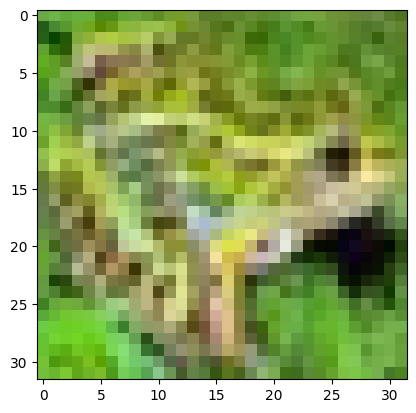

In [52]:
import matplotlib.pyplot as plt
plt.imshow(next(iter(train_loader))[0][0].permute(1,2,0))

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir lightning_logs/

In [55]:
from pytorch_lightning.callbacks import ModelCheckpoint

torch.set_float32_matmul_precision('medium')

model = ConvNeXt(out_features=10)
trainer = pl.Trainer(precision="16-mixed", max_epochs=500, log_every_n_steps=5, check_val_every_n_epoch=3, callbacks=[ModelCheckpoint(dirpath="checkpoints", monitor="val_loss", mode="min", every_n_epochs=3)])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=test_loader)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name        | Type               | Params | Mode 
------------------------------------------------------------
0  | patchify    | Conv2d             | 4.6 K  | train
1  | norm1       | LayerNorm          | 192    | train
2  | activation  | GELU               | 0      | train
3  | layer1      | Sequential         | 151 K  | train
4  | layer2      | Sequential         | 970 K  | train
5  | layer3      | Sequential         | 11.0 M | train
6  | layer4      | Sequential         | 15.4 M | train
7  | avg_pool    | AdaptiveAvgPool2d  | 0      | train
8  | norm2       | LayerNorm          | 1.5 K  | train
9  | fc          | Linear             | 7.7 K  | train
10 | accuracy    | MulticlassAccuracy | 0      | train
11 | gpu_augment | Sequential         | 0      | train
12 | mixup       | Mi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [70]:
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=test_loader)

/venv/main/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /workspace/lightning_logs/version_6/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name        | Type               | Params | Mode
-----------------------------------------------------------
0  | patchify    | Conv2d             | 4.6 K  | eval
1  | norm1       | LayerNorm          | 192    | eval
2  | activation  | GELU               | 0      | eval
3  | layer1      | Sequential         | 151 K  | eval
4  | layer2      | Sequential         | 970 K  | eval
5  | layer3      | Sequential         | 11.0 M | eval
6  | layer4      | Sequential         | 15.4 M | eval
7  | avg_pool    | AdaptiveAvgPool2d  | 0      | eval
8  | norm2       | LayerNorm          | 1.5 K  | eval
9  | fc          | Linear             | 7.7 K  | eval
10 | accuracy    | MulticlassAccuracy | 0      | eval
11 | gpu_augment | Sequential         | 0      | eval
12 | mix

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f060fff1800>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1646, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^Exception ignored in: ^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'<function _MultiProcessingDataLoaderIter.__del__ at 0x7f060fff1800>

 Traceback (most recent call last):
   File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
      self._shutdown_workers() 
   File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1646, in _shutdown_workers
      if w.is_alive(): 
     ^ ^  ^ ^^^^^^^^^^^^^^^^^^^^^^

...

Validation: |          | 0/? [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f060fff1800>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1646, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f060fff1800>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 16

Validation: |          | 0/? [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f060fff1800>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1646, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f060fff1800>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 16

NameError: name 'exit' is not defined

Our best accuracy is ~74.9%. Quite bad. We could probably make some improvements, but for now this isn't too bad.